# K-Means Clustering - Twitter Dataset

**Dataset Columns:** id, text, created_at, username, likes, topic

**Pipeline:** Clean Text → Generate Embeddings → K-Means Clustering → Visualize

---

## 1. Setup

In [1]:

!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn plotly umap-learn tqdm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import umap
import re
from tqdm import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("All libraries imported!")

All libraries imported!


## 2. Load Data

In [3]:
# Load your CSV
df = pd.read_csv('trendingtopics_cleaned.csv')  # or 'twitter_data_cleaned.csv' if you saved it from EDA

print(f"Dataset: {len(df):,} tweets")
print(f"Columns: {list(df.columns)}")
print(f"\nTopics: {df['topic'].unique()}")
df

Dataset: 8,257 tweets
Columns: ['id', 'text', 'created_at', 'username', 'likes', 'retweets', 'topic', 'timestamp', 'text_length', 'is_retweet', 'datetime', 'date', 'hour', 'day_of_week', 'has_url', 'has_mention', 'has_hashtag', 'has_emoji']

Topics: <StringArray>
['Super Bowl LX', 'Winter Olympics 2026 Milano', 'Bangladesh Election 2026']
Length: 3, dtype: str


,id,text,created_at,username,likes,retweets,topic,timestamp,text_length,is_retweet,datetime,date,hour,day_of_week,has_url,has_mention,has_hashtag,has_emoji
0,1960875468531621946,@PsyGuy007 bien vue super les gars...,2025-08-28,JaegerStep78492,0.0,NaN,Super Bowl LX,NaN,37,False,2025-08-28,2025-08-28,0,Thursday,False,True,False,False
1,1960973143008292871,"You know what, I've ALSO been a splendid nigga...",2025-08-28,JSRingo,209.0,NaN,Super Bowl LX,NaN,147,False,2025-08-28,2025-08-28,0,Thursday,False,False,False,False
2,1961159089544990909,@fashion_nfl Don’t think enough people are tal...,2025-08-28,p23rce,479.0,NaN,Super Bowl LX,NaN,79,False,2025-08-28,2025-08-28,0,Thursday,False,True,False,True
3,1961193691605078397,🤚🤚🤚💙2026!!!,2025-08-28,defloody,1.0,NaN,Winter Olympics 2026 Milano,NaN,11,False,2025-08-28,2025-08-28,0,Thursday,False,False,False,True
4,1961003661548741029,Super sleepy. https://t.co/FMEc5ShIuv,2025-08-28,FajitaFantom,17.0,NaN,Super Bowl LX,NaN,37,False,2025-08-28,2025-08-28,0,Thursday,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8252,"""2028188410528100663",Fire emblem fates method in 2026 ooowee,2026-03-01,tivstippi,1018.0,NaN,Bangladesh Election 2026,NaN,39,False,2026-03-01,2026-03-01,0,Sunday,False,False,False,False
8253,"""2028196713404498110",@DanielBursan ישראל אפרטהייד 2026,2026-03-01,michaelrommy2,4.0,NaN,Bangladesh Election 2026,NaN,33,False,2026-03-01,2026-03-01,0,Sunday,False,True,False,True
8254,"""2028109238380151207",Roderic O'Gorman of the Green Party is getting...,2026-03-01,MickOKeeffe,24924.0,NaN,Bangladesh Election 2026,NaN,310,False,2026-03-01,2026-03-01,0,Sunday,False,False,False,False
8255,"""2028160771054768308",@therealworld_ai @Cobratate 2026 https://t.co/...,2026-03-01,sollyhustles,30.0,NaN,Bangladesh Election 2026,NaN,56,False,2026-03-01,2026-03-01,0,Sunday,True,True,False,False


## 3. Simple Data Preprocessing

In [4]:
!pip install deep-translator

In [6]:
from deep_translator import GoogleTranslator
from langdetect import detect
from tqdm import tqdm
import time

# First detect languages
print("🔍 Detecting languages...")
df['detected_lang'] = 'en'

for idx in tqdm(df.index, desc="Language detection"):  # Sample first 1000
    try:
        text = df.loc[idx, 'text']
        if len(str(text).strip()) > 10:
            df.loc[idx, 'detected_lang'] = detect(str(text))
    except:
        pass

# Show language distribution
lang_counts = df['detected_lang'].value_counts()
print(f"\n📊 Language Distribution:")
for lang, count in lang_counts.items():
    print(f"   • {lang}: {count} ({count/len(df)*100:.1f}%)")

non_english = (df['detected_lang'] != 'en').sum()
print(f"\n⚠️  Non-English tweets to translate: {non_english}")

# Now translate with progress
print("\n🌐 Translating to English...")

def translate_and_clean(row):
    text = str(row['text'])
    lang = row['detected_lang']
    
    # Translate if needed
    if lang != 'en' and len(text.strip()) > 10:
        try:
            translator = GoogleTranslator(source='auto', target='en')
            text = translator.translate(text)
            time.sleep(0.05)
        except:
            pass
    
    # Clean
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'^RT\s+', '', text)
    text = ' '.join(text.split())
    
    return text.strip()

tqdm.pandas(desc="Translating & cleaning")
df['text_cleaned'] = df.progress_apply(translate_and_clean, axis=1)

print(f"\n✅ Translation complete!")
print(f"\n📝 Translation Examples:")
print("="*80)

# Show translations
translated_df = df[df['detected_lang'] != 'en'].head(5)
for idx, row in translated_df.iterrows():
    print(f"\n🌐 [{row['detected_lang'].upper()}] {row['text'][:80]}...")
    print(f"🇬🇧 [EN] {row['text_cleaned'][:80]}...")
    print("-"*80)

🔍 Detecting languages...


Language detection: 100%|██████████| 8257/8257 [00:28<00:00, 291.97it/s]



📊 Language Distribution:
   • en: 6619 (80.2%)
   • es: 289 (3.5%)
   • pt: 211 (2.6%)
   • fr: 186 (2.3%)
   • de: 126 (1.5%)
   • he: 126 (1.5%)
   • id: 120 (1.5%)
   • it: 111 (1.3%)
   • tr: 34 (0.4%)
   • ja: 34 (0.4%)
   • af: 32 (0.4%)
   • pl: 32 (0.4%)
   • ar: 32 (0.4%)
   • ca: 29 (0.4%)
   • tl: 24 (0.3%)
   • nl: 24 (0.3%)
   • no: 20 (0.2%)
   • th: 20 (0.2%)
   • sv: 19 (0.2%)
   • bn: 16 (0.2%)
   • ro: 15 (0.2%)
   • da: 14 (0.2%)
   • so: 13 (0.2%)
   • hr: 12 (0.1%)
   • cy: 11 (0.1%)
   • fi: 9 (0.1%)
   • hi: 8 (0.1%)
   • sl: 7 (0.1%)
   • sw: 7 (0.1%)
   • ru: 7 (0.1%)
   • et: 6 (0.1%)
   • zh-cn: 6 (0.1%)
   • lt: 5 (0.1%)
   • sq: 5 (0.1%)
   • vi: 4 (0.0%)
   • uk: 3 (0.0%)
   • el: 3 (0.0%)
   • ko: 3 (0.0%)
   • ta: 3 (0.0%)
   • cs: 2 (0.0%)
   • hu: 2 (0.0%)
   • ne: 2 (0.0%)
   • lv: 1 (0.0%)
   • ur: 1 (0.0%)
   • ml: 1 (0.0%)
   • mk: 1 (0.0%)
   • zh-tw: 1 (0.0%)
   • fa: 1 (0.0%)

⚠️  Non-English tweets to translate: 1638

🌐 Translating to English.

Translating & cleaning: 100%|██████████| 8257/8257 [39:10<00:00,  3.51it/s]  


✅ Translation complete!

📝 Translation Examples:

🌐 [FR] @PsyGuy007 bien vue super les gars......
🇬🇧 [EN] good view great guys......
--------------------------------------------------------------------------------

🌐 [AF] Super sleepy. https://t.co/FMEc5ShIuv...
🇬🇧 [EN] Super sleepy....
--------------------------------------------------------------------------------

🌐 [PT] E PORCA BUTTANA MI TIRO UN SEGONE DUA LIPA ALL'OLIMPICO NEL 2026...
🇬🇧 [EN] AND HOLY BITCH I'LL GET A HANDJOB WITH DUA LIPA AT THE OLIMPICO IN 2026...
--------------------------------------------------------------------------------

🌐 [IT] Come funziona il super laser anti droni OW5-A50 made in China? https://t.co/57uJ...
🇬🇧 [EN] How does the OW5-A50 anti-drone super laser made in China work?...
--------------------------------------------------------------------------------

🌐 [ES] La suerte está echada: Con ustedes todos los enfrentamientos que viviremos en la...
🇬🇧 [EN] The die is cast: With you all the confront

In [26]:
df.to_csv('trendingtopics_translated.csv', index=False)
print("\nTranslated dataset saved")


Translated dataset saved


In [10]:
from langdetect import detect, LangDetectException

def detect_lang(text):
    try:
        if len(str(text).strip()) > 10:
            return detect(str(text))
        return 'unknown'
    except:
        return 'unknown'

df['detected_lang'] = df['text_cleaned'].apply(detect_lang)

lang_counts = df['detected_lang'].value_counts()

print(f"Language Distribution of all the tweets):\n")
for lang, count in lang_counts.head(10).items():
    pct = count / len(df) * 100
    print(f"  {lang}: {count} ({pct:.1f}%)")

print(f"\nEnglish tweets: {(df['detected_lang'] == 'en').sum()} ({(df['detected_lang'] == 'en').sum()/len(df)*100:.1f}%)")

Language Distribution of all the tweets):

  en: 7680 (93.0%)
  unknown: 93 (1.1%)
  de: 65 (0.8%)
  id: 51 (0.6%)
  af: 38 (0.5%)
  bn: 34 (0.4%)
  ca: 29 (0.4%)
  fr: 28 (0.3%)
  it: 28 (0.3%)
  tl: 22 (0.3%)

English tweets: 7680 (93.0%)


## 4. Generate Embeddings (Hugging Face Model)

In [11]:
MODEL_NAME = 'all-MiniLM-L6-v2'

print(f"Loading model: {MODEL_NAME}")
print("First run will download the model...\n")

model = SentenceTransformer(MODEL_NAME)

print(f"Model loaded!")
print(f"Embedding dimensions: {model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {model.max_seq_length} tokens")

Loading model: all-MiniLM-L6-v2
First run will download the model...



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!
Embedding dimensions: 384
Max sequence length: 256 tokens


In [12]:
# Generate embeddings
print(f"Generating embeddings for {len(df):,} tweets...")
print("This may take a few minutes...\n")

texts = df['text_cleaned'].tolist()

# Encode with progress bar
embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f"\nEmbeddings generated!")
print(f"Shape: {embeddings.shape}")
print(f"   • {embeddings.shape[0]:,} tweets")
print(f"   • {embeddings.shape[1]} dimensions each")

# Save embeddings
np.save('twitter_embeddings.npy', embeddings)
print("\nSaved to 'twitter_embeddings.npy'")

Generating embeddings for 8,257 tweets...
This may take a few minutes...



Batches:   0%|          | 0/259 [00:00<?, ?it/s]


Embeddings generated!
Shape: (8257, 384)
   • 8,257 tweets
   • 384 dimensions each

Saved to 'twitter_embeddings.npy'


In [13]:
# Quick check: similarity between tweets
from sklearn.metrics.pairwise import cosine_similarity

# Compare first two tweets
sim = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
print(f"Sample similarity check:")
print(f"\nTweet 1: {texts[0][:80]}...")
print(f"Tweet 2: {texts[1][:80]}...")
print(f"\nCosine similarity: {sim:.4f}")
print(f"Interpretation: {sim:.2f} means {'similar' if sim > 0.5 else 'different'} content")

Sample similarity check:

Tweet 1: good view great guys......
Tweet 2: You know what, I've ALSO been a splendid nigga as of late, I deserve a reward. T...

Cosine similarity: 0.1797
Interpretation: 0.18 means different content


## 5. Find Optimal K (Elbow Method)

In [14]:
# Test different K values
K_range = range(2, 21)  # Test K = 2 to 20

inertias = []
silhouette_scores = []
davies_bouldin_scores = []

print("Testing different K values...")
print("This will take a few minutes...\n")

for k in tqdm(K_range, desc="Testing K"):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(embeddings, labels))
    davies_bouldin_scores.append(davies_bouldin_score(embeddings, labels))

print("\nAnalysis complete!")

Testing different K values...
This will take a few minutes...



Testing K: 100%|██████████| 19/19 [00:49<00:00,  2.62s/it]


Analysis complete!


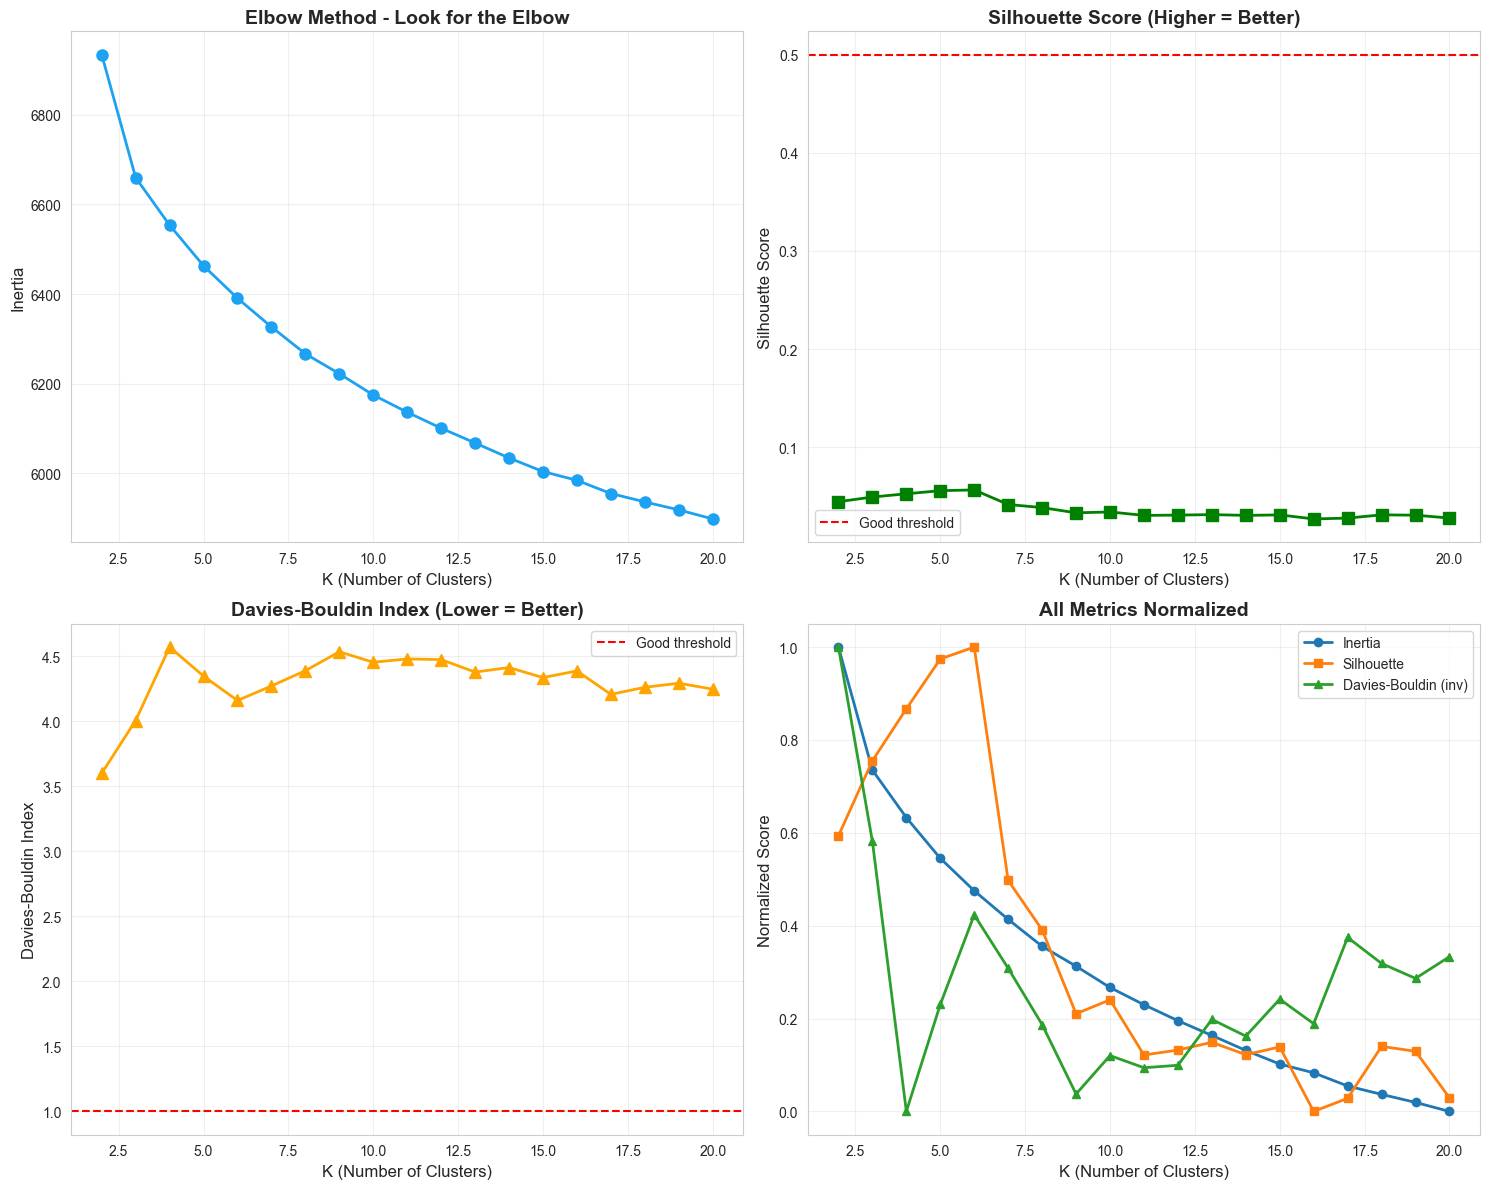

In [15]:
# Visualize metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Elbow curve (inertia)
axes[0, 0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#1DA1F2')
axes[0, 0].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[0, 0].set_ylabel('Inertia', fontsize=12)
axes[0, 0].set_title('Elbow Method - Look for the Elbow', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Silhouette score (higher is better)
axes[0, 1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (Higher = Better)', fontsize=14, fontweight='bold')
axes[0, 1].axhline(y=0.5, color='red', linestyle='--', label='Good threshold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Davies-Bouldin (lower is better)
axes[1, 0].plot(K_range, davies_bouldin_scores, marker='^', linewidth=2, markersize=8, color='orange')
axes[1, 0].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (Lower = Better)', fontsize=14, fontweight='bold')
axes[1, 0].axhline(y=1.0, color='red', linestyle='--', label='Good threshold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. All normalized
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
axes[1, 1].plot(K_range, scaler.fit_transform(np.array(inertias).reshape(-1, 1)).flatten(), 
                marker='o', label='Inertia', linewidth=2)
axes[1, 1].plot(K_range, scaler.fit_transform(np.array(silhouette_scores).reshape(-1, 1)).flatten(), 
                marker='s', label='Silhouette', linewidth=2)
axes[1, 1].plot(K_range, 1 - scaler.fit_transform(np.array(davies_bouldin_scores).reshape(-1, 1)).flatten(), 
                marker='^', label='Davies-Bouldin (inv)', linewidth=2)
axes[1, 1].set_xlabel('K (Number of Clusters)', fontsize=12)
axes[1, 1].set_ylabel('Normalized Score', fontsize=12)
axes[1, 1].set_title('All Metrics Normalized', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Metrics table
metrics_df = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertias,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores
})

print("METRICS SUMMARY:\n")
print(metrics_df.to_string(index=False))

best_k_sil = metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'K']
best_k_db = metrics_df.loc[metrics_df['Davies-Bouldin'].idxmin(), 'K']

print(f"\n🏆 Best K by Silhouette: {best_k_sil} (score: {metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'Silhouette']:.4f})")
print(f"🏆 Best K by Davies-Bouldin: {best_k_db} (score: {metrics_df.loc[metrics_df['Davies-Bouldin'].idxmin(), 'Davies-Bouldin']:.4f})")

print(f"\nRecommended K range: {best_k_sil - 2} to {best_k_sil + 2}")
print(f"Look for the 'elbow' in the inertia plot above!")

METRICS SUMMARY:

 K     Inertia  Silhouette  Davies-Bouldin
 2 6933.624512    0.044588        3.600947
 3 6659.409180    0.049357        4.007427
 4 6553.458008    0.052658        4.572523
 5 6462.863770    0.055830        4.348781
 6 6390.532227    0.056587        4.161339
 7 6326.717773    0.041746        4.273064
 8 6266.751953    0.038608        4.390748
 9 6222.371582    0.033272        4.536139
10 6174.946777    0.034158        4.455631
11 6136.534180    0.030650        4.481146
12 6100.994141    0.030962        4.475952
13 6068.084473    0.031456        4.380032
14 6034.706055    0.030669        4.414966
15 6004.373047    0.031160        4.337668
16 5984.780762    0.027061        4.388963
17 5955.412598    0.027895        4.208486
18 5936.743652    0.031195        4.262978
19 5918.887695    0.030886        4.294197
20 5898.758301    0.027933        4.248782

🏆 Best K by Silhouette: 6 (score: 0.0566)
🏆 Best K by Davies-Bouldin: 2 (score: 3.6009)

Recommended K range: 4 to 8
Look

## 6. Train K-Means with Optimal K

In [17]:
# Set optimal K based on analysis above
OPTIMAL_K = 6 

print(f"Training K-Means with K = {OPTIMAL_K}...\n")

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=20,
    max_iter=300
)

cluster_labels = kmeans_final.fit_predict(embeddings)
df['cluster'] = cluster_labels

print("Training complete!\n")
print(f"Final Metrics:")
print(f"   • Inertia: {kmeans_final.inertia_:.2f}")
print(f"   • Silhouette: {silhouette_score(embeddings, cluster_labels):.4f}")
print(f"   • Davies-Bouldin: {davies_bouldin_score(embeddings, cluster_labels):.4f}")
print(f"   • Calinski-Harabasz: {calinski_harabasz_score(embeddings, cluster_labels):.2f}")

Training K-Means with K = 6...

Training complete!

Final Metrics:
   • Inertia: 6390.53
   • Silhouette: 0.0566
   • Davies-Bouldin: 4.1613
   • Calinski-Harabasz: 232.11


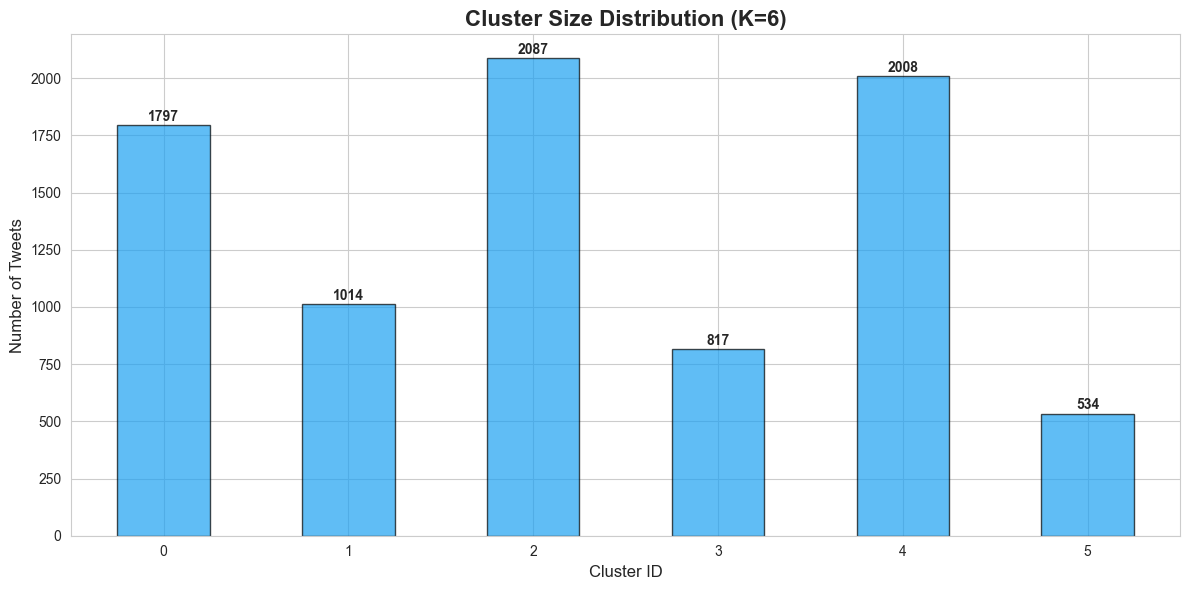


Cluster Statistics:
   • Largest: 2087 tweets (Cluster 2)
   • Smallest: 534 tweets (Cluster 5)
   • Average: 1376.2 tweets
   • Median: 1405.5 tweets


In [19]:
# Cluster size distribution
cluster_counts = df['cluster'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
cluster_counts.plot(kind='bar', color='#1DA1F2', edgecolor='black', alpha=0.7)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.title(f'Cluster Size Distribution (K={OPTIMAL_K})', fontsize=16, fontweight='bold')
plt.xticks(rotation=0)

for i, v in enumerate(cluster_counts):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCluster Statistics:")
print(f"   • Largest: {cluster_counts.max()} tweets (Cluster {cluster_counts.idxmax()})")
print(f"   • Smallest: {cluster_counts.min()} tweets (Cluster {cluster_counts.idxmin()})")
print(f"   • Average: {cluster_counts.mean():.1f} tweets")
print(f"   • Median: {cluster_counts.median():.1f} tweets")

## 7. Analyze Clusters by Original Topic

📊 CLUSTER vs TOPIC Distribution:

topic    Bangladesh Election 2026  Super Bowl LX  Winter Olympics 2026 Milano
cluster                                                                      
0                               0           1713                           84
1                             258            504                          252
2                             137             39                         1911
3                              13            153                          651
4                               6           1698                          304
5                               0             16                          518



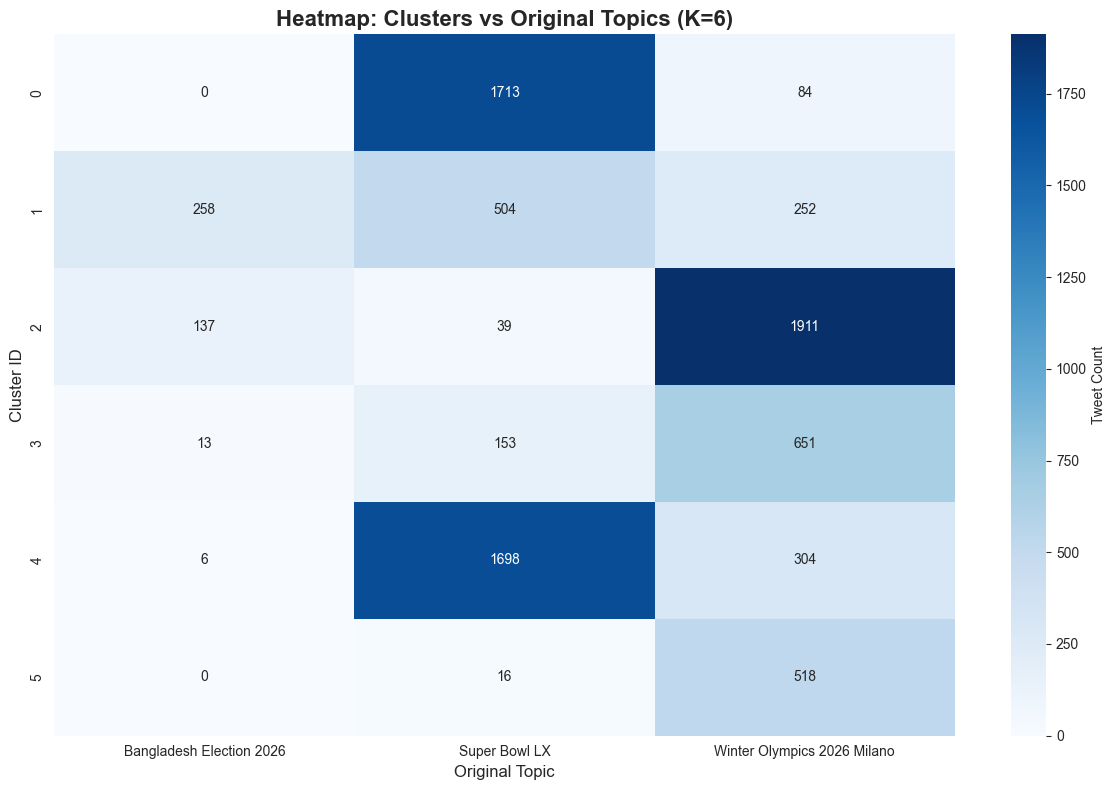


💡 This shows how well clusters align with original topics
💡 Diagonal dominance = good clustering


In [20]:
# Cross-tabulation: Clusters vs Original Topics
cluster_topic_matrix = pd.crosstab(df['cluster'], df['topic'])

print("📊 CLUSTER vs TOPIC Distribution:\n")
print(cluster_topic_matrix)
print("\n" + "="*80)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_topic_matrix, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Tweet Count'})
plt.title(f'Heatmap: Clusters vs Original Topics (K={OPTIMAL_K})', fontsize=16, fontweight='bold')
plt.xlabel('Original Topic', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.tight_layout()
plt.show()

print("\n💡 This shows how well clusters align with original topics")
print("💡 Diagonal dominance = good clustering")

## 8. Sample Tweets from Each Cluster

In [21]:
# Show sample tweets from each cluster
print("="*80)
print("SAMPLE TWEETS FROM EACH CLUSTER")
print("="*80)

for cluster_id in range(OPTIMAL_K):
    cluster_tweets = df[df['cluster'] == cluster_id]
    
    print(f"\n{'='*80}")
    print(f"🔹 CLUSTER {cluster_id} ({len(cluster_tweets)} tweets)")
    print(f"{'='*80}")
    
    # Show topic distribution in this cluster
    topic_dist = cluster_tweets['topic'].value_counts()
    print(f"\nTopic distribution:")
    for topic, count in topic_dist.items():
        print(f"  • {topic}: {count} ({count/len(cluster_tweets)*100:.1f}%)")
    
    # Show 5 random samples
    samples = cluster_tweets.sample(min(5, len(cluster_tweets)), random_state=42)
    
    print(f"\nSample tweets:")
    for i, (idx, row) in enumerate(samples.iterrows(), 1):
        print(f"{i}. [{row['topic']}] ❤️ {row['likes']:,}")
        print(f"   {row['text_cleaned'][:150]}...")
        print()

print("="*80)
print("\nan you identify themes in each cluster?")
print("In Week 7, LLMs will auto-generate cluster names!")

SAMPLE TWEETS FROM EACH CLUSTER

🔹 CLUSTER 0 (1797 tweets)

Topic distribution:
  • Super Bowl LX: 1713 (95.3%)
  • Winter Olympics 2026 Milano: 84 (4.7%)

Sample tweets:
1. [Super Bowl LX] ❤️ 509,060.0
   SHOULD THE #GIANTS HIRE JON GRUDEN AS THEIR NEXT HEAD COACH…?Gruden is a Super Bowl champion and is in the Bucs Ring of Honor.Jon is considered a quar...

2. [Super Bowl LX] ❤️ 2,015.0
   you gotta really hook the bowl up to your liking or you gone fuck yo shit up....

3. [Super Bowl LX] ❤️ 35.0
   Make your lunch decadent with our Grilled Veggie and #Avocado Bowl with sour cream added ������ #comfortfood #lombard #tacos #womanownedbusiness...

4. [Super Bowl LX] ❤️ 19,628.0
   Hits Daily Double fuels speculation on Adele performing at the 2026 Super Bowl:“If Adele books the halftime show, as has been rumored (and we've yet t...

5. [Super Bowl LX] ❤️ 10.0
   With eight super bowl rings, it's hard to watch someone else coach anything. Especially, when his are the only balls to deflat

## 9. Simple Keyword Extraction per Cluster

In [23]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def extract_keywords(texts, top_n=10):
    all_words = []
    for text in texts:
        words = text.lower().split()
        # Filter stopwords, URLs, mentions
        words = [w for w in words if w not in ENGLISH_STOP_WORDS 
                 and len(w) > 3 
                 and not w.startswith(('http', '@', '#'))]
        all_words.extend(words)
    
    word_freq = Counter(all_words)
    return word_freq.most_common(top_n)

print("📊 TOP KEYWORDS PER CLUSTER\n")
print("="*80)

for cluster_id in range(OPTIMAL_K):
    tweets = df[df['cluster'] == cluster_id]['text_cleaned'].tolist()
    keywords = extract_keywords(tweets, top_n=10)
    
    print(f"\nCluster {cluster_id} ({len(tweets)} tweets):")
    kw_list = [f"{word}({count})" for word, count in keywords]
    print(f"   {', '.join(kw_list)}")

print("\n" + "="*80)
print("\nThese are simple frequency-based keywords")

📊 TOP KEYWORDS PER CLUSTER


Cluster 0 (1797 tweets):
   super(1661), bowl(1409), halftime(416), bunny(168), bowl.(164), like(154), just(135), time(99), watch(98), people(96)

Cluster 1 (1014 tweets):
   super(420), election(143), 2026(113), people(83), like(70), trump(66), just(63), bangladesh(46), it's(42), winter(38)

Cluster 2 (2087 tweets):
   2026(1353), 2026.(225), ������(207), year(139), 2026,(116), february(97), 2026?(78), january(77), 2026:(61), like(58)

Cluster 3 (817 tweets):
   2026(218), olympics(176), super(126), winter(98), world(97), ������(67), team(49), ������������(48), olympics.(46), like(41)

Cluster 4 (2008 tweets):
   super(1495), ������(203), 2026(138), like(137), just(119), great(76), &amp;(76), bowl(74), it's(64), power(61)

Cluster 5 (534 tweets):
   winter(401), winter.(48), ������(43), like(35), just(35), weather(28), time(26), it's(23), storm(21), snow(21)


These are simple frequency-based keywords


## 10. Save All Results

In [ ]:
# Save everything
df.to_csv('twitter_with_clusters.csv', index=False)
print("Saved: twitter_with_clusters.csv")

np.save('twitter_embeddings.npy', embeddings)
print("Saved: twitter_embeddings.npy")

np.save('cluster_labels.npy', cluster_labels)
print("Saved: cluster_labels.npy")

np.save('embeddings_pca.npy', embeddings_pca)
np.save('embeddings_umap.npy', embeddings_umap)
print("Saved: PCA and UMAP coordinates")

print("\nAll results saved!")